# THE OSCARS
## 1927-2024

### Integrantes
* Antônio Duarte
* Guilherme Ribeiro
* João Gabriel
* Josué Mykael

### Introdução
O objetivo deste projeto é investigar a diversidade e a representatividade nos Oscars ao longo da história da premiação, analisando fatores como gênero, raça e nacionalidade entre indicados e vencedores.

Além disso, o projeto busca compreender se acontecimentos sociais influenciaram mudanças na Academia do Oscar, principalmente após o movimento #OscarsSoWhite.

### Análise Inicial

In [147]:
import pandas as pd

In [148]:
df_oscar_incompleto = pd.read_csv("datasets/oscarwinners.csv")
df_oscar_completo = pd.read_csv("datasets/oscar2024.csv")
df_imdb = pd.read_csv("datasets/world_imdb_movies_top_movies_per_year.csv")

In [149]:
print(list(df_imdb.columns))

['id', 'title', 'link', 'year', 'duration', 'rating_mpa', 'rating_imdb', 'vote', 'budget', 'gross_world_wide', 'gross_us_canada', 'gross_opening_weekend', 'director', 'writer', 'star', 'genre', 'country_origin', 'filming_location', 'production_company', 'language', 'win', 'nomination', 'oscar']


In [150]:
print("\nInformações sobre os dados IMDB:")
df_imdb.info()


Informações sobre os dados IMDB:
<class 'pandas.DataFrame'>
RangeIndex: 33600 entries, 0 to 33599
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     33600 non-null  str    
 1   title                  33600 non-null  str    
 2   link                   33600 non-null  str    
 3   year                   33600 non-null  int64  
 4   duration               33379 non-null  str    
 5   rating_mpa             25624 non-null  str    
 6   rating_imdb            33462 non-null  float64
 7   vote                   33462 non-null  float64
 8   budget                 11815 non-null  float64
 9   gross_world_wide       18222 non-null  float64
 10  gross_us_canada        17571 non-null  float64
 11  gross_opening_weekend  15523 non-null  float64
 12  director               33241 non-null  str    
 13  writer                 32024 non-null  str    
 14  star                   33127 no

In [151]:
print("\nInformações sobre os dados Oscar (1929 até 2014):")
df_oscar_incompleto.info()


Informações sobre os dados Oscar (1929 até 2014):
<class 'pandas.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                425 non-null    str    
 1   birth_year          425 non-null    int64  
 2   birth_date          424 non-null    str    
 3   birthplace          425 non-null    str    
 4   race_ethnicity      425 non-null    str    
 5   religion            159 non-null    str    
 6   sexual_orientation  425 non-null    str    
 7   year_edition        425 non-null    float64
 8   category            425 non-null    str    
 9   movie               425 non-null    str    
dtypes: float64(1), int64(1), str(8)
memory usage: 33.3 KB


In [152]:
print("\nInformações sobre os dados Oscar (1929 até 2024):")
df_oscar_completo.info()


Informações sobre os dados Oscar (1929 até 2024):
<class 'pandas.DataFrame'>
RangeIndex: 10889 entries, 0 to 10888
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   year_film      10889 non-null  int64
 1   year_ceremony  10889 non-null  int64
 2   ceremony       10889 non-null  int64
 3   category       10889 non-null  str  
 4   name           10884 non-null  str  
 5   film           10570 non-null  str  
 6   winner         10889 non-null  bool 
dtypes: bool(1), int64(3), str(3)
memory usage: 521.2 KB


### Passo 1: Filtragem
Primeiramente, foi removido de "oscar2024" a parte que falta para complementar os vencedores em "oscarwinners", e complementado em "oscarwinners" manualmente as informações dos vencedores de 2025 e 2026.

In [153]:
import pandas as pd

In [154]:
df = pd.read_csv("datasets/oscar2024.csv")

Nesse bloco foi feita uma filtragem dos dados que serão necessários para a análise:

In [155]:
filtro_anos = df["year_film"].between(2014, 2024)
filtro_vencedores = (df["winner"] == True)

In [156]:
categorias_principais = [ 
    "DIRECTING",
    "ACTOR IN A LEADING ROLE",
    "ACTRESS IN A LEADING ROLE",
    "ACTOR IN A SUPPORTING ROLE",
    "ACTRESS IN A SUPPORTING ROLE",
]

filtro_categorias = df["category"].isin(categorias_principais)

In [157]:
df_resultado = df[filtro_anos & filtro_vencedores & filtro_categorias]
df_resultado.head()

,year_film,year_ceremony,ceremony,category,name,film,winner
9644,2014,2015,87,ACTOR IN A LEADING ROLE,Eddie Redmayne,The Theory of Everything,True
9649,2014,2015,87,ACTOR IN A SUPPORTING ROLE,J.K. Simmons,Whiplash,True
9652,2014,2015,87,ACTRESS IN A LEADING ROLE,Julianne Moore,Still Alice,True
9655,2014,2015,87,ACTRESS IN A SUPPORTING ROLE,Patricia Arquette,Boyhood,True
9675,2014,2015,87,DIRECTING,Alejandro G. Iñárritu,Birdman or (The Unexpected Virtue of Ignorance),True


E tudo foi transformado em um csv novo, contendo apenas os vencedores de 2014 a 2024.

In [158]:
df_resultado.to_csv("datasets/oscar_vencedores_2014_2024.csv", index=False)

### Passo 2: Organizar
Nesse passo, foi organizado o novo csv para deixá-lo compatível com o "oscarwinners" e uni-los.

In [159]:
import pandas as pd
import numpy as np

In [160]:
df_24 = pd.read_csv('datasets/oscar_vencedores_2014_2024.csv')

As categorias foram padronizadas para facilitar o merge.

In [161]:
mapa_categorias = {
    'ACTOR IN A LEADING ROLE': 'Best Actor',
    'ACTOR IN A SUPPORTING ROLE': 'Best Supporting Actor',
    'ACTRESS IN A LEADING ROLE': 'Best Actress',
    'ACTRESS IN A SUPPORTING ROLE': 'Best Supporting Actress',
    'DIRECTING': 'Best Director'
}

df_24['category'] = df_24['category'].replace(mapa_categorias)
print(df_24['category'].head())

0                 Best Actor
1      Best Supporting Actor
2               Best Actress
3    Best Supporting Actress
4              Best Director
Name: category, dtype: str


In [162]:
df_24 = df_24.rename(columns={
    'film': 'movie',
    'year_ceremony': 'year_edition'
})

In [163]:
colunas = [
    'name', 
    'birth_year', 
    'birth_date', 
    'birthplace', 
    'race_ethnicity', 
    'religion', 
    'sexual_orientation', 
    'year_edition', 
    'category', 
    'movie' ]

df_24_padronizado = df_24.reindex(columns=colunas)

In [164]:
df_24_padronizado.to_csv("datasets/oscar_vencedores_2014_2024_organizado.csv", index=False)

Visto isso, completamos manualmente as informações (ano de nascimento, etnia, e orientação sexual) dos 52 vencedores faltantes com informações públicas e declarações étnicas dos mesmos, e formamos um NOVO csv, oscar_vencedores_2014_2024_completo.

### Passo 3: União
Nesse passo, foram unidos o "oscar_vencedores_2014_2024_organizado" a "oscarwinners".

In [165]:
import pandas as pd

In [166]:
df_antigo = pd.read_csv('datasets/oscarwinners.csv')
df_novo = pd.read_csv('datasets/oscar_vencedores_2014_2024_completo.csv')

A função concat foi usada para uni-los.

In [167]:
df_oscar_completo = pd.concat([df_antigo, df_novo], ignore_index=True)
print(df_oscar_completo.tail())

                     name  birth_year birth_date birthplace race_ethnicity  \
471        Cillian Murphy        1976        NaN        NaN          White   
472     Robert Downey Jr.        1965        NaN        NaN          White   
473            Emma Stone        1988        NaN        NaN          White   
474  Da'Vine Joy Randolph        1986        NaN        NaN          Black   
475     Christopher Nolan        1970        NaN        NaN          White   

    religion sexual_orientation  year_edition                 category  \
471      NaN           Straight        2024.0               Best Actor   
472      NaN           Straight        2024.0    Best Supporting Actor   
473      NaN           Straight        2024.0             Best Actress   
474      NaN           Straight        2024.0  Best Supporting Actress   
475      NaN           Straight        2024.0            Best Director   

             movie  
471    Oppenheimer  
472    Oppenheimer  
473    Poor Things  
47

In [168]:
df_oscar_completo.to_csv('datasets/oscartotal.csv', index=False, encoding='utf-8')

O csv novo abrange de 1929 (primeira cerimônia do oscar) até 2024. Portanto, para deixar mais completo, foram manualmente adicionados os vencedores de 2025 e 2026.

Nessa etapa, foram unidos o csv de vencedores do oscar, que contém todos os vencedores de 1929 até 2026, com o dataset do imdb para unir as informações gerais dos filmes em que os vencedores participaram.

In [169]:
df_oscar = pd.read_csv('datasets/oscartotal.csv')
df_imdb = pd.read_csv('datasets/world_imdb_movies_top_movies_per_year.csv')

Foi feita uma padronização para que o link com o nome do título seja feita corretamente, deixando todas as letras minusculas e tirando duplicatas para o título não aparecer 2 vezes.

In [170]:
df_oscar['movie_clean'] = df_oscar['movie'].astype(str).str.strip().str.lower()
df_imdb['title_clean'] = df_imdb['title'].astype(str).str.strip().str.lower()

df_imdb_unique = df_imdb.drop_duplicates(subset=['title_clean'], keep='first')

In [171]:
df_merged = pd.merge(
    df_oscar, 
    df_imdb_unique, 
    left_on='movie_clean', 
    right_on='title_clean', 
    how='left'
)

df_merged.tail()

,name,birth_year,birth_date,birthplace,race_ethnicity,religion,sexual_orientation,year_edition,category,movie,...,star,genre,country_origin,filming_location,production_company,language,win,nomination,oscar,title_clean
471,Cillian Murphy,1976,NaN,NaN,White,NaN,Straight,2024.0,Best Actor,Oppenheimer,...,"Cillian Murphy, Emily Blunt, Matt Damon","Docudrama, Epic, Historical Epic, Period Drama...","United States, United Kingdom","Los Alamos, New Mexico, USA","Universal Pictures, Atlas Entertainment, Gadge...","English, German, Italian, Dutch",0.0,369.0,0.0,oppenheimer
472,Robert Downey Jr.,1965,NaN,NaN,White,NaN,Straight,2024.0,Best Supporting Actor,Oppenheimer,...,"Cillian Murphy, Emily Blunt, Matt Damon","Docudrama, Epic, Historical Epic, Period Drama...","United States, United Kingdom","Los Alamos, New Mexico, USA","Universal Pictures, Atlas Entertainment, Gadge...","English, German, Italian, Dutch",0.0,369.0,0.0,oppenheimer
473,Emma Stone,1988,NaN,NaN,White,NaN,Straight,2024.0,Best Actress,Poor Things,...,"Emma Stone, Mark Ruffalo, Willem Dafoe","Dark Comedy, Steampunk, Comedy, Drama, Romance...","Ireland, United Kingdom, United States, Hungary","Origo Film Studio, Budapest, Hungary","Element Pictures, Film4, Fruit Tree","English, French, Portuguese",0.0,414.0,0.0,poor things
474,Da'Vine Joy Randolph,1986,NaN,NaN,Black,NaN,Straight,2024.0,Best Supporting Actress,The Holdovers,...,"Paul Giamatti, DaVine Joy Randolph, Dominic Sessa","Holiday Comedy, Comedy, Drama, Holiday",United States,"Groton School, 282 Farmers Row, Groton, Massac...","Miramax, CAA Media Finance, Gran Via Productions",English,0.0,206.0,0.0,the holdovers
475,Christopher Nolan,1970,NaN,NaN,White,NaN,Straight,2024.0,Best Director,Oppenheimer,...,"Cillian Murphy, Emily Blunt, Matt Damon","Docudrama, Epic, Historical Epic, Period Drama...","United States, United Kingdom","Los Alamos, New Mexico, USA","Universal Pictures, Atlas Entertainment, Gadge...","English, German, Italian, Dutch",0.0,369.0,0.0,oppenheimer


In [172]:
df_merged.to_csv('datasets/oscar_imdb_merged.csv', index=False)

Por fim, foi executada a alteração manual de Hispanic, Middle Eastern e Multiracial com base em afirmações próprias dos atores para reduzir a 3 etnias, visto que eram poucas a fazer a alteração.

In [173]:
df_oscar = pd.read_csv('datasets/oscar_imdb_merged.csv')
df_oscar['race_ethnicity'].value_counts(dropna=False)

race_ethnicity
White    442
Black     24
Asian     10
Name: count, dtype: int64

Checagem para ver quem são:

In [174]:
hispanic = df_oscar[df_oscar['race_ethnicity'].str.strip().str.lower() == 'hispanic']
print(hispanic)

Empty DataFrame
Columns: [name, birth_year, birth_date, birthplace, race_ethnicity, religion, sexual_orientation, year_edition, category, movie, movie_clean, id, title, link, year, duration, rating_mpa, rating_imdb, vote, budget, gross_world_wide, gross_us_canada, gross_opening_weekend, director, writer, star, genre, country_origin, filming_location, production_company, language, win, nomination, oscar, title_clean]
Index: []

[0 rows x 35 columns]


In [175]:
multi = df_oscar[df_oscar['race_ethnicity'].str.strip().str.lower() == 'multiracial']
print(multi)

Empty DataFrame
Columns: [name, birth_year, birth_date, birthplace, race_ethnicity, religion, sexual_orientation, year_edition, category, movie, movie_clean, id, title, link, year, duration, rating_mpa, rating_imdb, vote, budget, gross_world_wide, gross_us_canada, gross_opening_weekend, director, writer, star, genre, country_origin, filming_location, production_company, language, win, nomination, oscar, title_clean]
Index: []

[0 rows x 35 columns]


In [176]:
middle = df_oscar[df_oscar['race_ethnicity'].str.strip().str.lower() == 'middle eastern']
print(middle)

Empty DataFrame
Columns: [name, birth_year, birth_date, birthplace, race_ethnicity, religion, sexual_orientation, year_edition, category, movie, movie_clean, id, title, link, year, duration, rating_mpa, rating_imdb, vote, budget, gross_world_wide, gross_us_canada, gross_opening_weekend, director, writer, star, genre, country_origin, filming_location, production_company, language, win, nomination, oscar, title_clean]
Index: []

[0 rows x 35 columns]


Antes do age_at_win, foi adicionado manualmente o ano de aniversário dos vencedores de 2014 a 2026 que não constavam no csv original "oscar2024".

In [177]:
df_oscar['sexual_orientation'] = df_oscar['sexual_orientation'].fillna('Unknown')
df_oscar['religion'] = df_oscar['religion'].fillna('Unknown')
df_oscar['age_at_win'] = df_oscar['year_edition'] - df_oscar['birth_year']

In [178]:
df_oscar['age_at_win'].head()

0    63.0
1    62.0
2    73.0
3    67.0
4    53.0
Name: age_at_win, dtype: float64

In [179]:
df_oscar.to_csv('datasets/oscar_imdb_merged.csv', index=False, encoding='utf-8')

### Passo 4: Análise
Nesse passo, com todas as informaçôes reunidas, foi iniciada a análise, fazendo uma organização no csv final nas categorias que seriam investigadas.

In [180]:
import pandas as pd

In [181]:
df_oscar = pd.read_csv('datasets/oscar_imdb_merged.csv')
df_oscar['sexual_orientation'].value_counts(dropna=False)

sexual_orientation
Straight             433
Bisexual              21
Na                    10
Gay                    7
Matter of Dispute      3
Lesbian                2
Name: count, dtype: int64

In [182]:
df_oscar['race_ethnicity'].value_counts(dropna=False)

race_ethnicity
White    442
Black     24
Asian     10
Name: count, dtype: int64

In [183]:
df_oscar.shape

(476, 36)

A análise gráfica:

In [184]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import linregress

Para fazer a análise de década, foi garantido que "year_edition" era numérico e feita a transformação para década. Ex.: 2023. Dividindo inteiramente por 10: 202; e multiplicando por 10: 2020; a validação evita erros.

In [185]:
df = pd.read_csv('datasets/oscar_imdb_merged.csv')

df['year_edition'] = pd.to_numeric(df['year_edition'], errors='coerce').fillna(0).astype(int)

df['decade'] = (df['year_edition'] // 10) * 10
df_valid = df[df['decade'] >= 1920].copy()

Proporção racial dos vencedores por década:

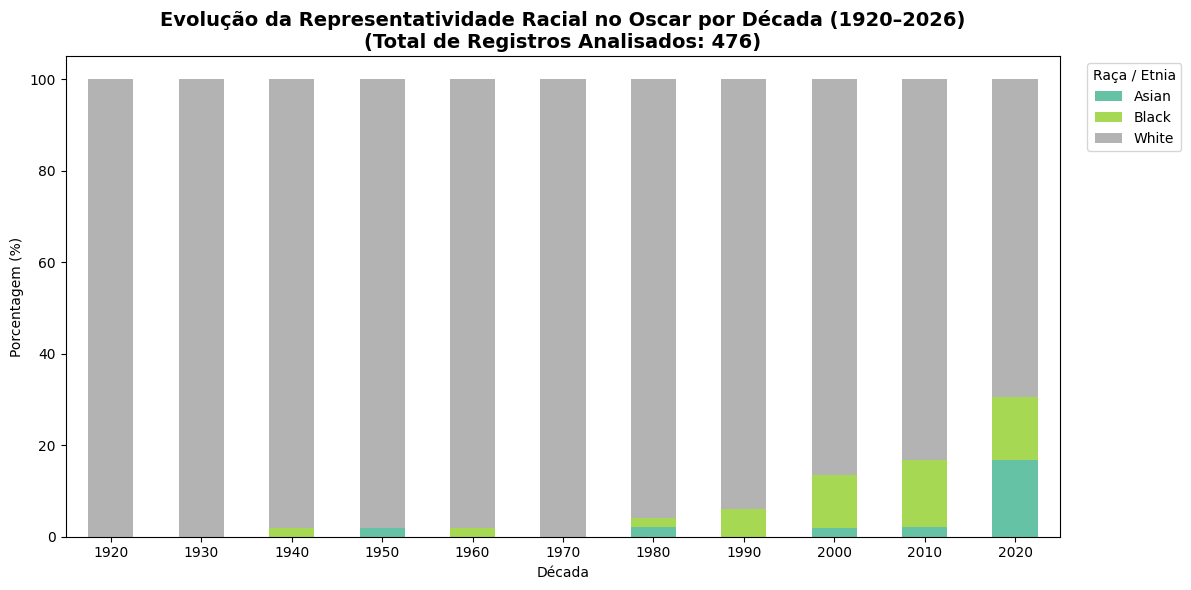

In [186]:
total = len(df_valid)

crosstab_race = pd.crosstab(df_valid['decade'], df_valid['race_ethnicity'], normalize='index') * 100

ax = crosstab_race.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set2')
plt.title(f'Evolução da Representatividade Racial no Oscar por Década (1920–2026)\n(Total de Registros Analisados: {total})', fontsize=14, fontweight='bold')
plt.xlabel('Década')
plt.ylabel('Porcentagem (%)')
plt.legend(title='Raça / Etnia', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Distribuição da representatividade por categoria de premiação:

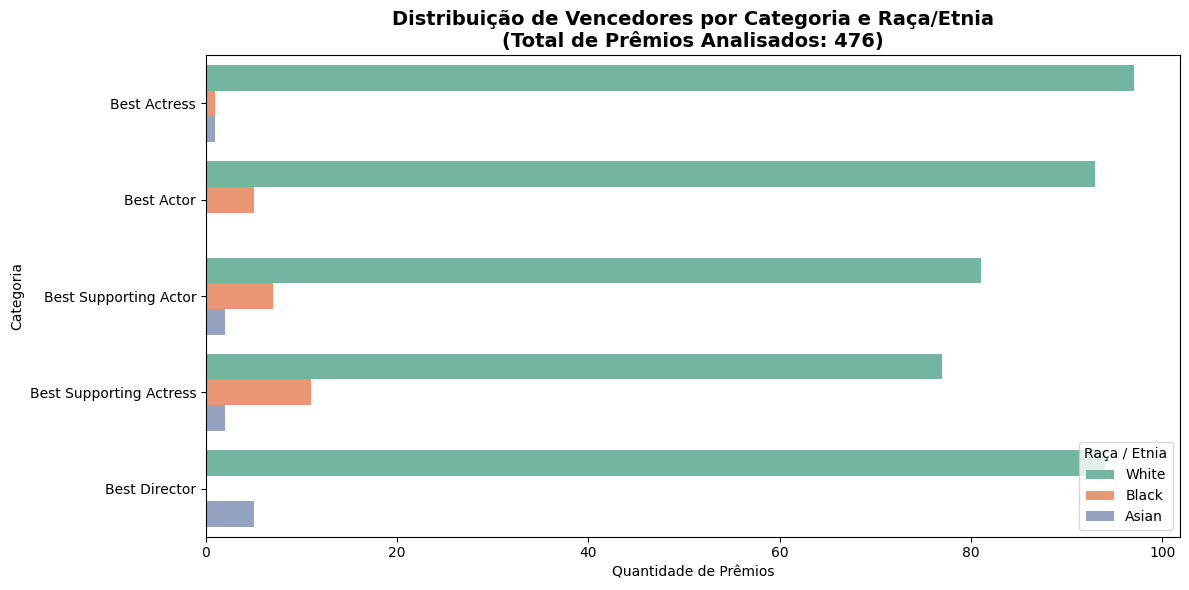

In [187]:
plt.figure(figsize=(12, 6))

sns.countplot(data=df, y='category', hue='race_ethnicity', palette='Set2')
plt.title(f'Distribuição de Vencedores por Categoria e Raça/Etnia\n(Total de Prêmios Analisados: {total})', fontsize=14, fontweight='bold')
plt.xlabel('Quantidade de Prêmios')
plt.ylabel('Categoria')
plt.legend(title='Raça / Etnia', loc='lower right')
plt.tight_layout()
plt.show()

Comparação entre a idade média em que homens e mulheres vencem o Oscar nas categorias de atuação:

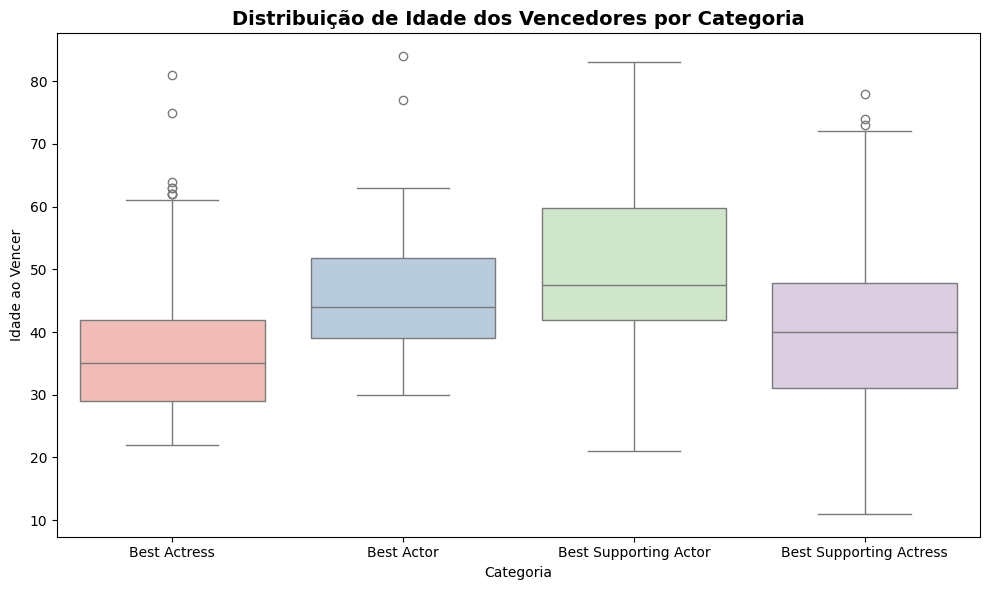

In [188]:
plt.figure(figsize=(10, 6))
categorias_atuacao = ['Best Actor', 'Best Actress', 'Best Supporting Actor', 'Best Supporting Actress']
df_atuacao = df_valid[df_valid['category'].isin(categorias_atuacao)].copy()

sns.boxplot(data=df_atuacao, x='category', y='age_at_win', hue='category', palette='Pastel1', legend=False)

plt.title('Distribuição de Idade dos Vencedores por Categoria', fontsize=14, fontweight='bold')
plt.xlabel('Categoria')
plt.ylabel('Idade ao Vencer')
plt.tight_layout()
plt.show()

Utilizando um gráfico de dispersão ao longo dos anos, é possível visualizar se o reconhecimento de artistas abertamente LGBTQIA+ é uma conquista recente ou se possui histórico nas primeiras edições do Oscar. Esse cruzamento permite entender não só a presença, mas a evolução temporal dessa representatividade.

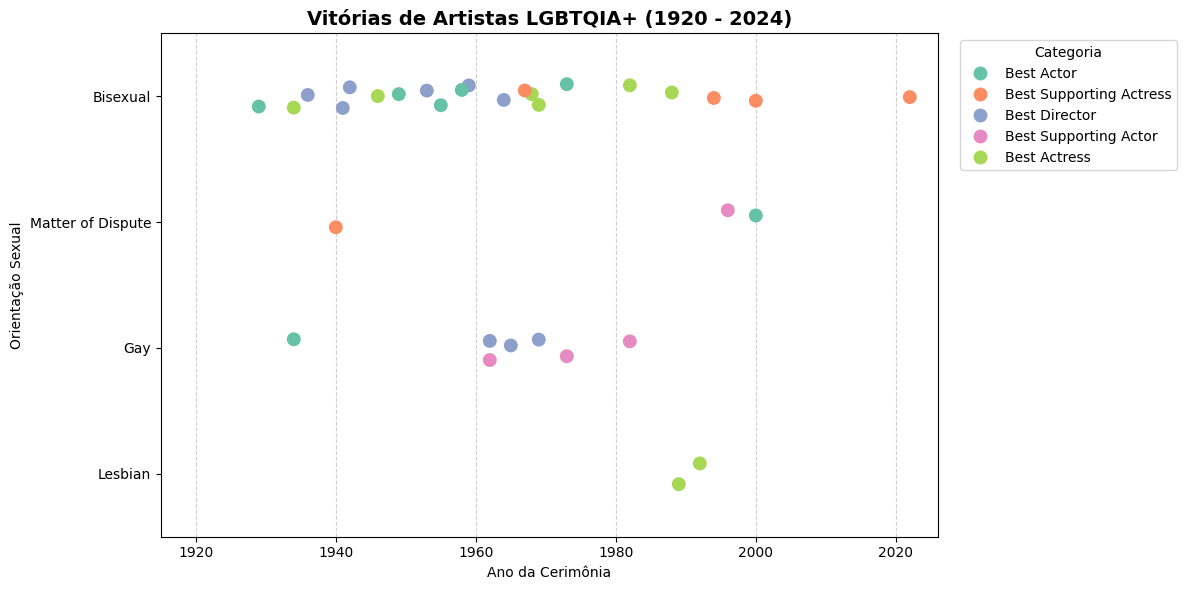

In [189]:
df_lgbt = df_valid[~df_valid['sexual_orientation'].str.strip().str.capitalize().isin(['Unknown', 'Straight', 'Na', 'Nan'])]

plt.figure(figsize=(12, 6))

sns.stripplot(
    data=df_lgbt, 
    x='year_edition', 
    y='sexual_orientation', 
    hue='category', 
    palette='Set2', 
    size=10,
    jitter=True 
)

plt.title('Vitórias de Artistas LGBTQIA+ (1920 - 2024)', fontsize=14, fontweight='bold')
plt.xlabel('Ano da Cerimônia')
plt.ylabel('Orientação Sexual')
plt.xlim(1915, 2026) 

plt.legend(title='Categoria', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(True, axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Para analisar se a inclusão gera retorno financeiro, é calculado o lucro limpo (Lucro bruto - Orçamento) de cada filme. Utilizando a mediana para evitar distorções e ter uma visão realista de qual grupo tende a lucrar mais de forma consistente

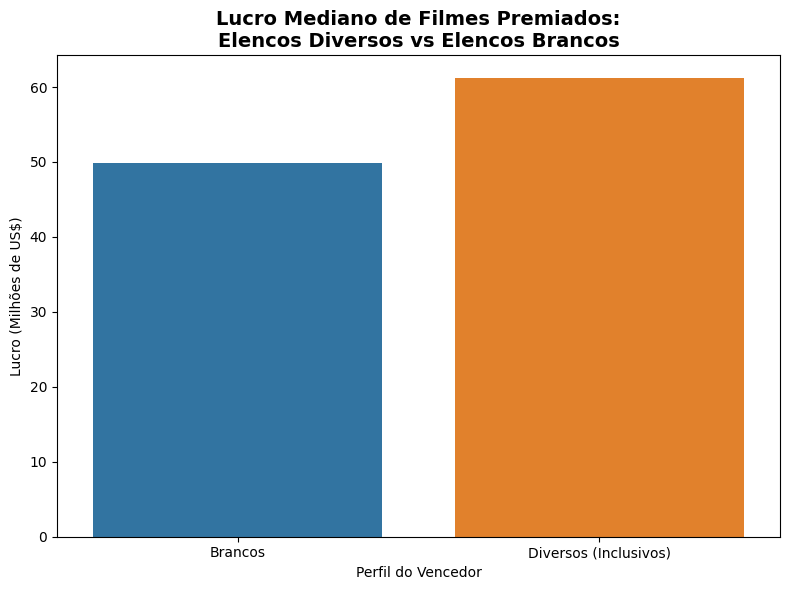

In [190]:
df_valid['perfil_racial'] = df_valid['race_ethnicity'].apply(
    lambda x: 'Brancos' if str(x).strip().lower() == 'white' else 'Diversos (Inclusivos)'
)
df_valid['orcamento'] = pd.to_numeric(df_valid['budget'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')
df_valid['bilheteria'] = pd.to_numeric(df_valid['gross_world_wide'].astype(str).str.replace(r'[^\d.]', '', regex=True), errors='coerce')

df_valid['lucro_milhoes'] = (df_valid['bilheteria'] - df_valid['orcamento']) / 1_000_000

df_financeiro = df_valid.dropna(subset=['lucro_milhoes'])

plt.figure(figsize=(8, 6))

sns.barplot(
    data=df_financeiro, 
    x='perfil_racial', 
    y='lucro_milhoes', 
    hue='perfil_racial',
    estimator=np.median,            
    legend=False,
    errorbar=None
)

plt.title('Lucro Mediano de Filmes Premiados:\nElencos Diversos vs Elencos Brancos', fontsize=14, fontweight='bold')
plt.xlabel('Perfil do Vencedor')
plt.ylabel('Lucro (Milhões de US$)')
plt.tight_layout()
plt.show()

Para comprovar matematicamente a diferença de retorno financeiro, aplica-se o modelo de Regressão Linear. 

O objetivo é encontrar a equação da reta y = ax + b para os dois grupos de vencedores (Brancos vs Diversos). O coeficiente angular a nos dirá exatamente quanto o lucro y aumenta para cada dólar investido no orçamento x. Ao plotarmos essas linhas de tendência, poderemos visualizar qual grupo possui a maior taxa de retorno.

Equação Brancos: y = 2.4924x + 52.97
Equação Diversos: y = -0.4822x + 113.98


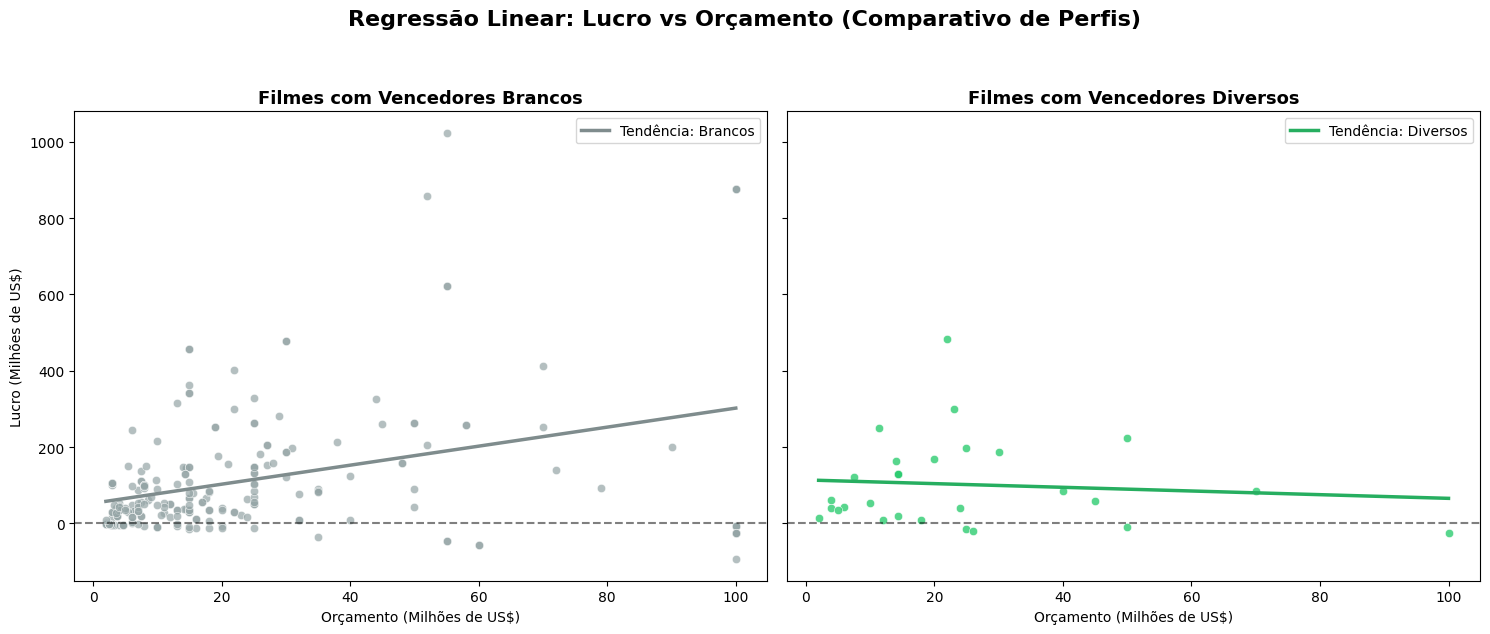

In [191]:
df_financeiro = df_financeiro.copy()
df_financeiro['orcamento_milhoes'] = df_financeiro['orcamento'] / 1_000_000
df_financeiro_limpo = df_financeiro.dropna(subset=['orcamento_milhoes', 'lucro_milhoes', 'perfil_racial'])

df_brancos = df_financeiro_limpo[df_financeiro_limpo['perfil_racial'] == 'Brancos'].copy()
df_diversos = df_financeiro_limpo[df_financeiro_limpo['perfil_racial'] == 'Diversos (Inclusivos)'].copy()

x_min = max(df_brancos['orcamento_milhoes'].min(), df_diversos['orcamento_milhoes'].min())
x_max = min(df_brancos['orcamento_milhoes'].max(), df_diversos['orcamento_milhoes'].max())

df_brancos = df_brancos[(df_brancos['orcamento_milhoes'] >= x_min) & (df_brancos['orcamento_milhoes'] <= x_max)]
df_diversos = df_diversos[(df_diversos['orcamento_milhoes'] >= x_min) & (df_diversos['orcamento_milhoes'] <= x_max)]

result_brancos = linregress(df_brancos['orcamento_milhoes'], df_brancos['lucro_milhoes'])
print(f"Equação Brancos: y = {result_brancos.slope:.4f}x + {result_brancos.intercept:.2f}")
result_diversos = linregress(df_diversos['orcamento_milhoes'], df_diversos['lucro_milhoes'])
print(f"Equação Diversos: y = {result_diversos.slope:.4f}x + {result_diversos.intercept:.2f}")

def f_brancos(x):
    return result_brancos.slope * x + result_brancos.intercept

def f_diversos(x):
    return result_diversos.slope * x + result_diversos.intercept

x_linha = np.linspace(x_min, x_max, 100)

linha_brancos = {'x': x_linha, 'y': f_brancos(x_linha)}
linha_diversos = {'x': x_linha, 'y': f_diversos(x_linha)}

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True, sharex=True)

sns.scatterplot(
    x='orcamento_milhoes', y='lucro_milhoes',
    data=df_brancos, color='#95a5a6', alpha=0.7, ax=axes[0]
)
sns.lineplot(
    x='x', y='y', data=linha_brancos,
    color='#7f8c8d', linewidth=2.5, label='Tendência: Brancos', ax=axes[0]
)
axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Filmes com Vencedores Brancos', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Orçamento (Milhões de US$)')
axes[0].set_ylabel('Lucro (Milhões de US$)')
axes[0].legend()

sns.scatterplot(
    x='orcamento_milhoes', y='lucro_milhoes',
    data=df_diversos, color='#2ecc71', alpha=0.8, ax=axes[1]
)
sns.lineplot(
    x='x', y='y', data=linha_diversos,
    color='#27ae60', linewidth=2.5, label='Tendência: Diversos', ax=axes[1]
)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Filmes com Vencedores Diversos', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Orçamento (Milhões de US$)')
axes[1].set_ylabel('')
axes[1].legend()

fig.suptitle('Regressão Linear: Lucro vs Orçamento (Comparativo de Perfis)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Conclusão

De acordo com nossas análises, verificamos que a quantidade de pessoas brancas vencedoras do Oscar ainda é significativamente maior do que a de pessoas pertencentes a outros grupos étnicos. Entretanto, observa-se que, a partir da década de 1980, essa diferença vem diminuindo gradualmente, indicando um aumento da diversidade étnico-racial entre os vencedores ao longo das últimas décadas.

Nas categorias individuais de atuação, como Melhor Ator e Melhor Atriz, os vencedores brancos ainda representam a maioria dos premiados. Entretanto, categorias como Melhor Ator Coadjuvante e Melhor Atriz Coadjuvante apresentam uma maior presença de vencedores negros e hispânicos, embora os atores brancos ainda sejam maioria nesses grupos de premiação.

Percebemos também que as mulheres tendem a conquistar o prêmio em idades mais jovens do que os homens. Entretanto, os homens apresentam uma maior longevidade no reconhecimento pela Academia, permanecendo elegíveis ou sendo premiados ao longo de um período mais extenso de suas carreiras.

Também foi verificado a presença de artistas LGBTQIA+ entre os vencedores do Oscar desde as primeiras décadas da premiação. Embora existam registros de reconhecimento desde o início da história da cerimônia, observa-se uma maior concentração dessas vitórias nas décadas mais recentes. Esse cenário pode estar relacionado ao aumento da visibilidade e da representatividade LGBTQIA+ na indústria cinematográfica ao longo do tempo.

Por fim, analisamos se a inclusão e a diversidade racial estão associadas ao retorno financeiro dos filmes premiados. Para isso, calculamos o lucro líquido de cada produção, obtido pela diferença entre a bilheteria mundial e o orçamento do filme, e utilizamos a mediana como medida de tendência central, buscando reduzir a influência de valores extremos. Os resultados indicam que os filmes associados a vencedores de grupos racialmente diversos apresentaram um lucro mediano superior ao daqueles associados a vencedores brancos, com aproximadamente US$ 83 milhões contra US$ 50 milhões, respectivamente. Esse resultado sugere que a diversidade não está necessariamente associada a um menor desempenho financeiro e pode coexistir com resultados comerciais positivos.

Após a análise de todo o material, concluímos que os resultados apontam para uma evolução gradual da representatividade no Oscar, embora ainda existam desigualdades que demonstram que a busca por uma maior diversidade e inclusão na indústria cinematográfica permanece relevante.
